# SpinLab CW-EPR Processing Tutorial
This notebook demonstrates a simple workflow for loading, processing, and plotting cw-EPR spectra.


## Loading CW-EPR Data

The next section loads an example CW-EPR dataset.

In [1]:
import spinlab as sl
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

path = '../data/BDPA-1DFieldSweep.DTA'
data = sl.load(path)
print(data)


values:
	3000 ndarray (float64)
dims:
	['B0']
coords:
	array([350.1       , 350.10100033, 350.10200067, ..., 353.09799933,
       353.09899967, 353.1       ], shape=(3000,))
attrs:
	'data_dim': 1
	'x_unit': 'G'
	'frequency': 9.852145
	'center_field': 3516.0
	'power': 0.6325
	+10 attrs


## Plotting the CW-EPR Spectrum

This notebook demonstrates a simple workflow for loading, processing, and plotting cw-EPR spectra.


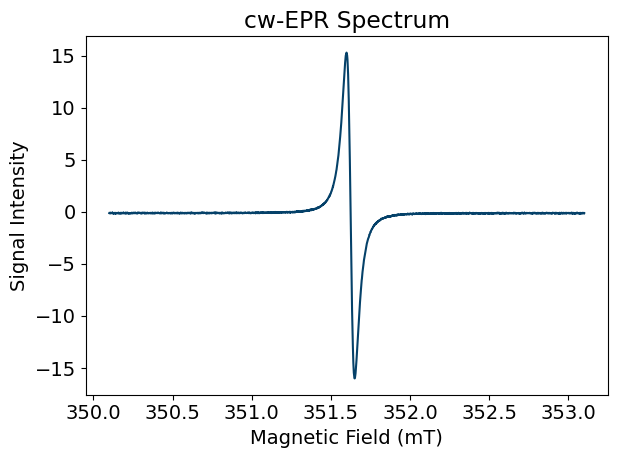

In [2]:
plt.figure()
sl.plot(data)
plt.xlabel('Magnetic Field (mT)')
plt.ylabel('Signal Intensity')
plt.title('cw-EPR Spectrum')
plt.tight_layout()
plt.show()


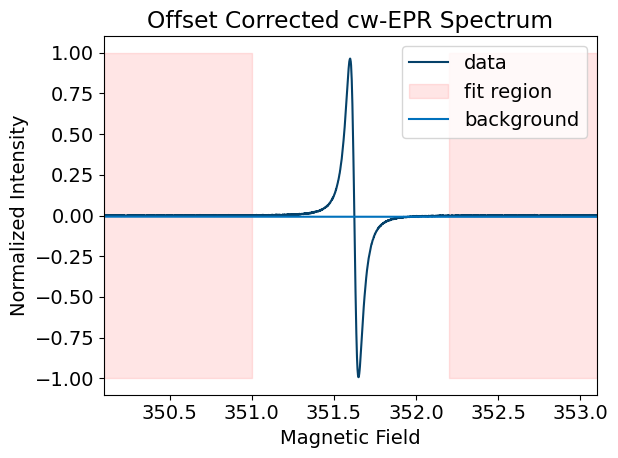

In [17]:
proc = data.copy()
proc /= np.max(np.abs(proc.values)) # Normalize to maximum of absolute value

field = proc.coords['B0']

region1 = (field[0], 351.0)
region2 = (352.2, field[-1])
background_fit = sl.background(proc, dim = 'B0', deg=1, regions = [region1,region2])

proc = proc - background_fit # remove background


plt.figure()
sl.plot(proc, label = 'data')
plt.fill_betweenx([-1,1], region1[0], region1[1], alpha = 0.1, color = 'red', label = 'fit region')
plt.fill_betweenx([-1,1], region2[0], region2[1], alpha = 0.1, color = 'red')
sl.plot(background_fit, label = 'background')
plt.xlabel('Magnetic Field')
plt.ylabel('Normalized Intensity')
plt.title('Offset Corrected cw-EPR Spectrum')
plt.xlim(field[0],field[-1])
plt.legend()
plt.tight_layout()
plt.show()


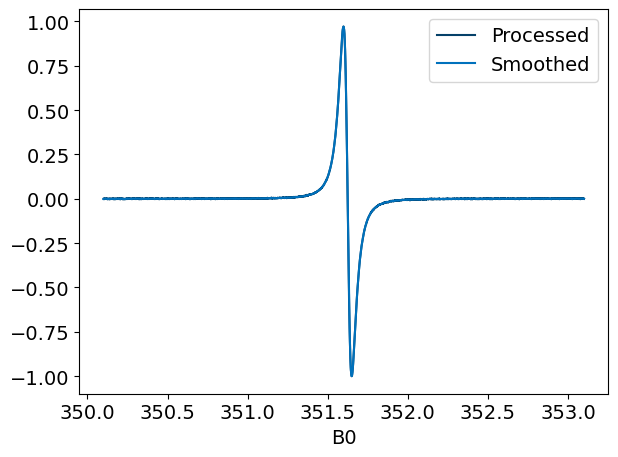

In [4]:
smooth = sl.smooth(proc, dim = 'B0', window_length=11)
plt.figure()
sl.plot(proc, label='Processed')
sl.plot(smooth, label='Smoothed')
plt.legend()
plt.tight_layout()
plt.show()


values:
	3000 ndarray (float64)
dims:
	['B0']
coords:
	array([350.1       , 350.10100033, 350.10200067, ..., 353.09799933,
       353.09899967, 353.1       ], shape=(3000,))
attrs:
	'data_dim': 1
	'x_unit': 'G'
	'frequency': 9.852145
	'center_field': 3516.0
	'power': 0.6325
	+10 attrs
Double Integral: 9289.074063528402


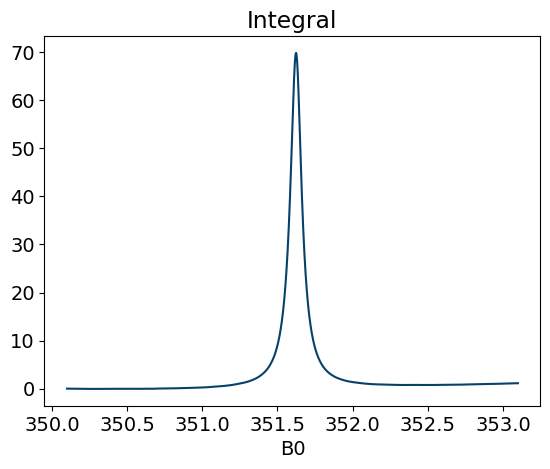

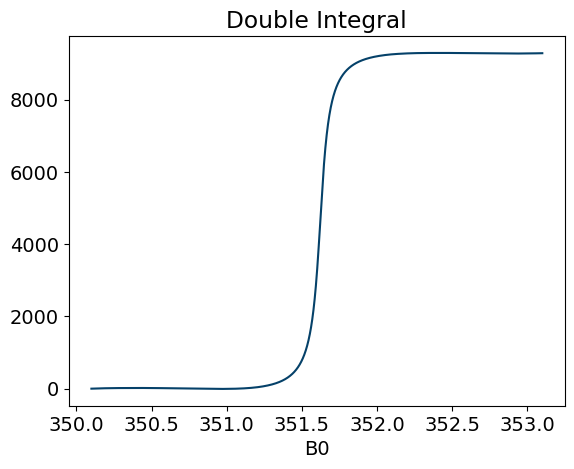

In [18]:
integral = smooth.cumulative_sum('B0')

integral_corrected = integral - sl.background(integral, dim = 'B0', deg=1, regions = [region1, region2]) # remove DC offset

double_integral = integral_corrected.cumulative_sum('B0')
print(double_integral)

plt.figure()
plt.title('Integral')
sl.plot(integral)
plt.figure()
plt.title('Double Integral')
sl.plot(double_integral)

double_integral_value = double_integral.values[-1]
print('Double Integral:', double_integral_value)

## Summary

In this notebook we introduced the basic CW-EPR importing and workflow.
